13 · Urban morphology

City2Graph has two morphological constructions:

- `segments_to_graph()`: homogeneous primal graph. Intersections are nodes,
  street segments are edges, street topology and nothing else.
- `morphological_graph()`: heterogeneous graph. Street segments are the
  channels movement is organized through (*public*), plots with their
  buildings are the units where activities take place (*private*). Three
  relations stitch it together: `(private, touched_to, private)` for
  contiguity between plots, `(public, connected_to, public)` for street
  continuity, `(private, faced_to, public)` for a plot facing the street.

Both become native SciGraphs objects below, colored by layer.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g
import geopandas as gpd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

ox = nb.osmnx()

# A small radius keeps this to seconds; tessellation is the expensive part.
CENTER = (39.5093, -0.4084)      # Burjassot, Valencia
RADIUS_M = 500
METRIC_CRS = "EPSG:25830"        # UTM 30N

print("city2graph", c2g.__version__, "| osmnx", ox.__version__)

city2graph 0.3.1 | osmnx 2.0.7


## 1 · Input data

OpenStreetMap via OSMnx, which answers in seconds. Overture Maps, the other
source city2graph supports natively, is the optional cell at the end.

In [2]:
G_streets = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="drive",
                                simplify=True)
nodes_ox, edges_ox = ox.graph_to_gdfs(G_streets)

buildings = ox.features_from_point(CENTER, tags={"building": True}, dist=RADIUS_M)
buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]

print(f"streets   {len(edges_ox):>6} segments, {len(nodes_ox)} intersections")
print(f"buildings {len(buildings):>6}")

streets      217 segments, 127 intersections
buildings   1023


city2graph works on projected GeoDataFrames. In degrees, a
threshold of "100" does not mean 100 meters and every distance computation
comes out wrong.

In [3]:
segments = edges_ox.to_crs(METRIC_CRS)[["geometry"]].reset_index(drop=True)
buildings_m = buildings.to_crs(METRIC_CRS)[["geometry"]].reset_index(drop=True)

print("CRS:", segments.crs, "|", buildings_m.crs)
check("both layers in the same metric CRS",
      segments.crs == buildings_m.crs and not segments.crs.is_geographic)

CRS: EPSG:25830 | EPSG:25830
[PASS] both layers in the same metric CRS


True

## 2 · Primal graph: `segments_to_graph()`

Returns `(nodes, edges)`, city2graph's canonical structure for homogeneous
graphs. Nodes are the segment endpoints; edges keep the street geometry.

In [4]:
nodes_primal, edges_primal = c2g.segments_to_graph(segments)

print(f"nodes {len(nodes_primal)}, edges {len(edges_primal)}")
print("edge index:", edges_primal.index.names)
edges_primal.head(3)

nodes 127, edges 217
edge index: ['from_node_id', 'to_node_id']


geometry
from_node_id to_node_id                                                   
0            123         LINESTRING (722328.383 4376377.163, 722325.782...
1            9           LINESTRING (722488.268 4376376.271, 722516.747...
             27          LINESTRING (722488.268 4376376.271, 722457.203...

That `MultiIndex (from_private_id, to_private_id)`, whatever it
is called in a given construction, is what SciGraphs uses to resolve which
vertices an edge joins. An edge GeoDataFrame with a flat index produces an
object with vertices and zero edges.

In [5]:
check("the edges carry a MultiIndex (source, target)",
      edges_primal.index.nlevels >= 2,
      f"levels: {edges_primal.index.nlevels}")

[PASS] the edges carry a MultiIndex (source, target) — levels: 2


True

### Into Blender

`sg.graphs.anchor_from()` creates the georeference object SciGraphs needs to
project. Without it `create_native_graph_from_gdfs` returns `None` without
saying anything. An OSMnx import from the panel leaves one behind; from a bare
GeoDataFrame you have to put it there.

In [6]:
sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(CENTER[0], CENTER[1], scale=0.001, name="Anchor_Morphology")

obj_primal = sg.graphs.from_gdf(
    nodes_primal, edges_primal,
    name="Primal_Streets", ref=anchor, coll="C2G_Morphology",
    markers={"graph_type": "segments_to_graph"})

print(sg.graphs.summary(obj_primal))
check("the primal graph is in the scene", obj_primal is not None)
check("it has mesh edges",
      obj_primal is not None and len(obj_primal.data.edges) > 0)

{'object': 'Primal_Streets', 'type': 'MESH', 'num_nodes': 127, 'num_edges': 179, 'is_directed': False, 'vertices': 127, 'mesh_edges': 179, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id'], 'graph_type': 'segments_to_graph'}
[PASS] the primal graph is in the scene
[PASS] it has mesh edges


True

### How the figures in these notebooks are made

The images come from EEVEE, not from the add-on's own engine.
`scene.render.engine = 'SCIGRAPHS'` rasterizes the GPU buffers of the
interactive preview: fast and faithful to the viewport, but it draws graphs
and nothing else, with no materials, shadows or ground.
`nb.figure()` switches the add-on onto its other display path
(`scigraphs_display_engine = 'GEOMETRY_NODES'`, a modifier instancing spheres
on the vertices and sweeping tubes along the edges), so the graph becomes
ordinary meshes that lights and shadows act on. `sg.context.add_context()`
fills that scene: a ground surface, and the OSM footprints extruded through
*the same anchor* as the graph and dropped to street level under it. The
prisms are display geometry; nothing downstream reads them.

`isolate=` defaults to `True` and hides every other mesh, which is wrong when
the context is the point, so every context render below passes
`isolate=False`.

Every figure here is straight down through an orthographic camera
(`render_eevee`'s default `view='TOP'`) with `look='ink'`, so what separates
them is the attribute they are colored by: here `layer_id`. The primal graph
is the exception, since `segments_to_graph()` gets geometry and only geometry,
so its mesh carries no scalar attribute and it renders in the look's neutral.

attributes on the primal graph:
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  node_id                      POINT   INT
Info: Geometry Nodes modifier added


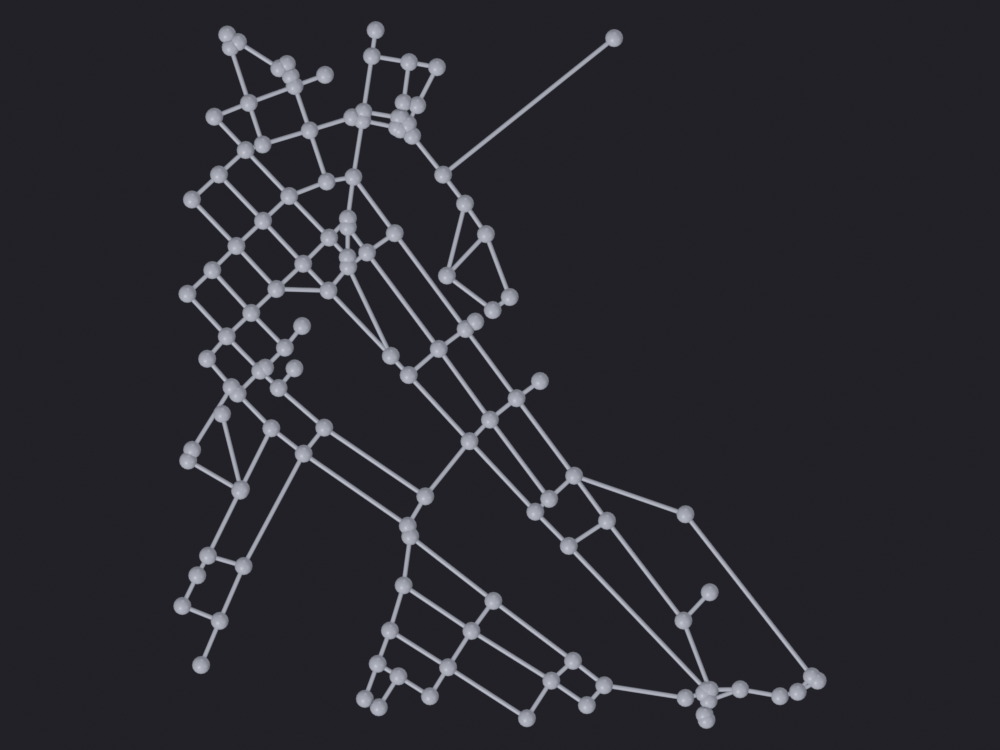

[PASS] 1_primal.png legible — 8.4% ink (healthy range 0.5–60%)


In [7]:
print("attributes on the primal graph:")
for name, domain, dtype in sg.graphs.attributes(obj_primal):
    print(f"  {name:<28} {domain:<7} {dtype}")

nb.figure(obj_primal, "renders/09_morphology/1_primal",
          look='ink')

## 3 · Tessellation: `create_tessellation()`

The heterogeneous graph needs the buildings turned into a system of plots, and
city2graph wraps momepy's morphological tessellation for it.

`primary_barriers` is the parameter that matters: with it the tessellation is
*enclosed* by the street network, each cell belonging to a block; without it
the cells cross the streets. The enclosed one is what a plot system needs.

In [8]:
# n_jobs=1 because the default -1 has momepy fork through joblib/loky, and the
# children do not inherit the add-on's sys.path inside Blender: every one dies
# with `ModuleNotFoundError: No module named 'joblib'`. It still finishes, but
# under a wall of tracebacks.
cells = c2g.create_tessellation(
    buildings_m,
    primary_barriers=segments,
    shrink=0.4,
    segment=0.5,
    n_jobs=1,
)

print(f"tessellation cells: {len(cells)}")
print("columns:", list(cells.columns))
cells.head(3)

tessellation cells: 475
columns: ['geometry', 'enclosure_index', 'tess_id']


,geometry,enclosure_index,tess_id
0,"POLYGON ((722394.016 4376344.657, 722394.012 4...",0,0_95
1,"POLYGON ((722394.809 4376414.14, 722396.266 43...",0,0_96
2,"POLYGON ((722392.81 4376360.867, 722392.372 43...",0,0_639


The same tessellation without barriers, for comparison:

In [9]:
cells_no_barriers = c2g.create_tessellation(buildings_m, shrink=0.4, segment=0.5,
                                            n_jobs=1)
print(f"with barriers   : {len(cells)} cells, mean area {cells.area.mean():.0f} m2")
print(f"without barriers: {len(cells_no_barriers)} cells, "
      f"mean area {cells_no_barriers.area.mean():.0f} m2")

check("the barriers change the result",
      abs(cells.area.mean() - cells_no_barriers.area.mean()) > 1.0,
      "if the areas match, the barriers are being ignored")

with barriers   : 475 cells, mean area 654 m2
without barriers: 1023 cells, mean area 1010 m2
[PASS] the barriers change the result — if the areas match, the barriers are being ignored


True

> **Warning about the equivalent SciGraphs operator.**
> `bpy.ops.scigraphs.c2g_generate_tessellation()` calls
> `create_tessellation(geometry=..., buildings=..., barriers=...)`, and
> `buildings` and `barriers` do not exist in the city2graph 0.3.1 API:
> `**kwargs` absorbs them and they are discarded without error. The result is
> always pure morphological tessellation, whatever you select as barriers in
> the panel. The correct name is `primary_barriers`; until the operator is
> fixed, use the direct call above.

### The cells, in Blender

This is not a graph, it is background geometry: polygons as faces.

In [10]:
objs_cells = sg.graphs.from_features(cells, name="Tessellation", ref=anchor,
                                     coll="C2G_Morphology")
objs_buildings = sg.graphs.from_features(buildings_m, name="Buildings", ref=anchor,
                                         coll="C2G_Morphology")

for obj in objs_cells + objs_buildings:
    print(f"  {obj.name:<24} {len(obj.data.vertices):>6} vertices, "
          f"{len(obj.data.polygons):>5} faces")

Using reference projection: center=(39.509300, -0.408400), scale=0.001
Created 1 object(s) from GeoDataFrame with 475 features
Using reference projection: center=(39.509300, -0.408400), scale=0.001
Created 1 object(s) from GeoDataFrame with 1023 features
  Tessellation               9872 vertices,   477 faces
  Buildings                  8154 vertices,  1070 faces


### The same buildings, as context under the graph

The SciGraphs engine draws graphs, and a tessellation is a polygon soup with
no nodes and no edges, so rendering these two objects through it gives an
empty frame. EEVEE has no such restriction, and the useful picture is the
street graph standing on the fabric it abstracts.

Three arguments deserve a note:

- `buildings_gdf=buildings` passes the untrimmed download, still carrying its
  OSM tags. `buildings_m` keeps only `geometry`, so a skyline built from it
  falls back to a constant. Read the tagged fraction the call prints before
  believing any height.
- `terrain_source="flat"` builds a plane and touches no network. Burjassot has
  a few meters of relief across the whole frame, not enough to see; notebook
  17 fetches a real DEM where it is.
- The context radius is larger than the study radius. The camera is
  orthographic and framed tight on the graph, and the frame is 4:3 while a
  terrain is square, so ground built at exactly the graph's radius leaves a
  strip of bare backdrop down each side, and not a symmetric one, since the
  graph is not centered on the anchor the way the terrain is. Half as much
  ground again costs nothing, the plane being generated rather than
  downloaded, and `buildings_gdf` was fetched at `RADIUS_M`, so a wider clip
  invents no footprints. Worth copying into every context render in the
  series.

In [11]:
# Same footprints at the graph's exact z. Coplanar surfaces z-fight, so these
# step out for the render.
for obj in objs_cells + objs_buildings:
    obj.hide_render = True

ctx = sg.context.add_context(obj_primal, CENTER, RADIUS_M * 1.5, anchor,
                             buildings_gdf=buildings,
                             terrain_source="flat")
print("real elevation:", ctx["real_elevation"])
sg.context.report(ctx["objects"])

Creating terrain mesh: 2x2 vertices
Terrain mesh created: 4 vertices, 1 faces
  flat ground, 1500 x 1500 m (no elevation data)
  1023 footprints -> 9224 faces, 16308 vertices
  heights: 15 from OSM tags (1.5%), the rest at 9.0 m (fallback constant)
  context moved -0.00100 Blender units (-1.0 m) so the ground clears z=0 by 1 m
[PASS] Context_Ground aligned with Primal_Streets — center off by 0.0423 BU (3.07% of the graph diagonal), covers 100.0% of it, 1.61x its width
[PASS] Context_Buildings aligned with Primal_Streets — center off by 0.0157 BU (1.14% of the graph diagonal), covers 100.0% of it, 1.05x its width
real elevation: False
  Context_Ground         ground     1.500 x 1.500 x 0.000 BU   source=flat real_elevation=False imagery=none
  Context_Buildings      buildings  0.979 x 1.068 x 0.018 BU   1023 footprints, 1% tagged, default 9.0 m (fallback constant)


### Turning the context down

An adjustment the composites here need and the ones in 03 do not. It is a
property of the *attribute*, not of the look.

`sg.context`'s palette was set against a light backdrop. On this frame it
puts the roofs at luminance 101 out of 255 and the ground at 65, where
notebook 15's zone plates land too, so the palette is not the odd one out. The
graph on top is what differs. In 03 the colormap is on the *edges* and takes
mid-ramp values, so the network reaches 146 to 202, 45 levels clear of its
context. Here it is on the nodes, and `layer_id` has exactly two values, so it
uses turbo's two endpoints, both of them its darkest stops: private nodes at
90, public at 61, *below* the roofs at 101. At normal viewing size the layer
split stops being visible at all.

61 is what turbo's top stop is worth under this rig, so the fabric comes down
instead. The albedos below put the roofs at 47 and the ground at 39 against a
backdrop of 33: an 8-level step, thin but readable because the prisms cast
shadows and catch the key at varying angles. The cost is that the buildings
read as texture rather than as the subject. The dimming goes in before the
first composite rather than between the two, so both composites of the same
place are made of the same material.

In [12]:
# Base colors only; the rest of `sg.context.material()` is left alone.
CONTEXT_ALBEDO = {"buildings": (0.033, 0.032, 0.029),
                  "terrain": (0.023, 0.024, 0.020),
                  "ground": (0.023, 0.024, 0.022)}


def dim_context(objects):
    """Scale the context materials down so the graph is the brightest thing."""
    done = {}
    for obj in objects:
        kind = obj.get("scigraphs_context_kind") or "ground"
        for mat in obj.data.materials:
            if mat is None or mat.name in done:
                continue
            node = next((n for n in mat.node_tree.nodes
                        if n.type == 'BSDF_PRINCIPLED'), None)
            if node is None or "Base Color" not in node.inputs:
                continue
            rgb = CONTEXT_ALBEDO.get(kind, CONTEXT_ALBEDO["ground"])
            node.inputs["Base Color"].default_value = (*rgb, 1.0)
            mat.diffuse_color = (*rgb, 1.0)
            done[mat.name] = (kind, rgb)
    return done


for name, (kind, rgb) in dim_context(ctx["objects"]).items():
    print(f"  {name:<26} {kind:<10} albedo {rgb}")

  SGNB_Context_ground        ground     albedo (0.023, 0.024, 0.022)
  SGNB_Context_buildings     buildings  albedo (0.033, 0.032, 0.029)


No satellite imagery under this one, although `add_context()`
will drape it and notebooks 16 and 17 use it. The footprints are already in
the frame as prisms, and a photograph of the same roofs would draw them a
second time.

Info: Geometry Nodes modifier added


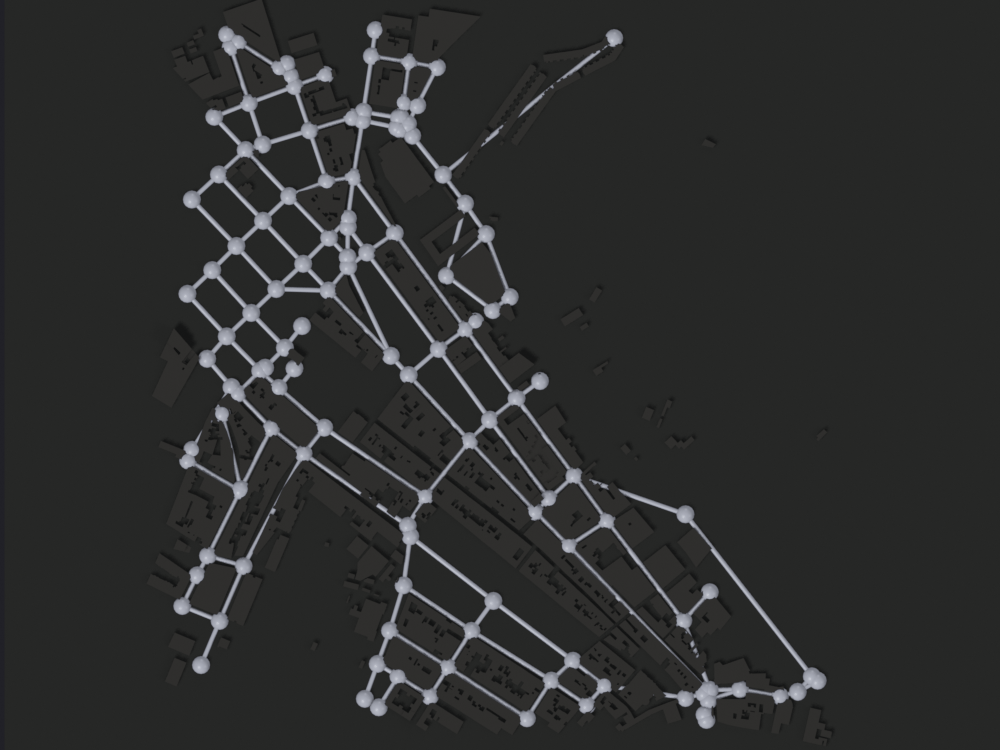

[PASS] 2_primal_context.png legible — 21.7% ink (healthy range 0.5–100%)


True

In [13]:
# Why every overhead context render here lifts `check_render`'s 60 % ink cap,
# explained once. `nb.ink()` counts pixels differing from the top-left pixel,
# which over full-frame ground is whatever the corner happens to land on: a
# sliver of backdrop there scores the figure 99.6 %, ground reaching the corner
# scores the same figure 24 %. A 0.99 ceiling would just fire on corner luck,
# so it is removed. The floor still catches an empty render, which scores 0.
path = nb.render(obj_primal, "renders/09_morphology/2_primal_context",
                 isolate=False, look='ink',
                 verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

## 4 · Morphological graph: `morphological_graph()`

The central construction of the module. Returns `(nodes_dict, edges_dict)`:

- `nodes_dict` has the keys `"private"` (tessellation cells) and `"public"`
  (street segments).
- `edges_dict` is indexed by **triplets** `(source_type, relation,
  target_type)`, city2graph's convention for heterogeneous graphs.

`clipping_buffer` clips around `center_point` to `distance` meters, left
generous so as not to lose any of the requested area.

In [14]:
from shapely.geometry import Point

center_m = gpd.GeoSeries([Point(CENTER[1], CENTER[0])], crs="EPSG:4326").to_crs(METRIC_CRS)

nodes_dict, edges_dict = c2g.morphological_graph(
    buildings_gdf=buildings_m,
    segments_gdf=segments,
    center_point=center_m,
    distance=RADIUS_M,
    clipping_buffer=100.0,
    contiguity="queen",
    keep_buildings=True,
    keep_segments=True,
)

nb.describe_hetero(nodes_dict, edges_dict)

expected = [("private", "touched_to", "private"),
            ("public", "connected_to", "public"),
            ("private", "faced_to", "public")]

for triplet in expected:
    check(f"relation {triplet}", triplet in edges_dict,
          f"{len(edges_dict[triplet])} edges" if triplet in edges_dict else "absent")

nodes
  private                    1616 Point
  public                      179 Point
edges
  private -> touched_to -> private                        870
  public -> connected_to -> public                        375
  private -> faced_to -> public                           974
[PASS] relation ('private', 'touched_to', 'private') — 870 edges
[PASS] relation ('public', 'connected_to', 'public') — 375 edges
[PASS] relation ('private', 'faced_to', 'public') — 974 edges


~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


### The heterograph, in Blender

All the layers land in a single mesh. Each vertex carries a `layer_id` and
each edge an `edge_type_id`, both integers, so the SciGraphs coloring
pipeline can pull the layers apart again.

In [15]:
obj_morpho = sg.graphs.from_hetero(
    nodes_dict, edges_dict,
    name="Morphological_Graph", ref=anchor, coll="C2G_Morphology",
    markers={"graph_type": "morphological_graph"})

print(sg.graphs.summary(obj_morpho))
print("\nattributes available for coloring:")
for name, domain, dtype in sg.graphs.attributes(obj_morpho):
    print(f"  {name:<28} {domain:<7} {dtype}")

check("the heterograph is in the scene", obj_morpho is not None)

{'object': 'Morphological_Graph', 'type': 'MESH', 'num_nodes': 1795, 'num_edges': 2219, 'is_directed': False, 'vertices': 1795, 'mesh_edges': 2219, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'layer_id', 'node_id', 'node_enclosure_index', 'edge_type_id', 'edge_weight', 'edge_enclosure_index'], 'layer_names': 'private,public', 'edge_type_names': 'private_touched_to_private,public_connected_to_public,private_faced_to_public', 'graph_type': 'morphological_graph'}

attributes available for coloring:
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  layer_id                     POINT   INT
  node_id                      POINT   INT
  node_enclosure_index         POINT   FLOAT
  edge_type_id                 EDGE    INT
  edge_weight                  EDGE    FLOAT
  edge_enclosure_index         EDGE    FLOAT
[PASS] the heterogr

True

`layer_id` is the attribute worth coloring by, and the
construction produced it. Two values, two ends of turbo: *private*
(tessellation cells) dark blue, *public* (street segments) red.

It is on the POINT domain, so the colormap lands on the node spheres and the
tubes take the look's `edge_color`, a neutral. That neutral has to sit below
both node colors, and ink's default does not, because turbo's endpoints are
the darkest stops on the ramp. It is set explicitly below, to the same value
in both figures, so the isolated graph and the composite are one drawing.

layer_id domain: POINT
  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> layer_id  ·  layer_id -> turbo [log]  [0 … 1] on Point


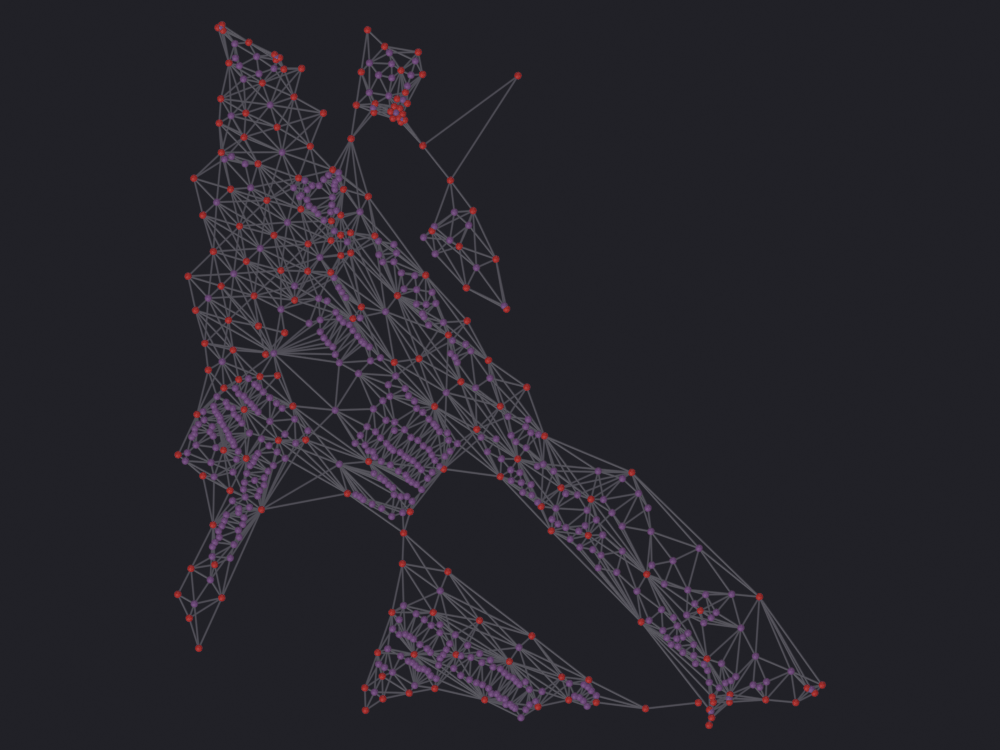

[PASS] 3_morphological.png legible — 14.7% ink (healthy range 0.5–60%)


In [16]:
print("layer_id domain:", sg.render.attribute_domain(obj_morpho, "layer_id"))

# Turbo's endpoints cap the node spheres at luminance 84, so brighter tubes
# bury the color. Ink's own 0.13 puts them at 89 and the violet private nodes
# dissolve; 0.19 reaches 118, and the 0.50 graph neutral gives a white web with
# dark beads. 0.085 lands at 75, under both node classes and still 28 levels
# clear of the dimmed roofs.
LAYER_EDGE_COLOR = (0.085, 0.080, 0.100)

nb.figure(obj_morpho, "renders/09_morphology/3_morphological",
          look='ink', color_attribute="layer_id",
          edge_color=LAYER_EDGE_COLOR)

The same graph over the buildings, the picture the whole
notebook is for: the *private* nodes are the tessellation cells wrapped around
those prisms.

`settle()` puts the ground one meter below the plane the graph is drawn on,
not below the roofs, so the network is at street level and the taller
buildings rise through it. Straight down that shows as a roof occluding the
edge behind it. That is a building, not an artifact.

  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> layer_id  ·  layer_id -> turbo [log]  [0 … 1] on Point


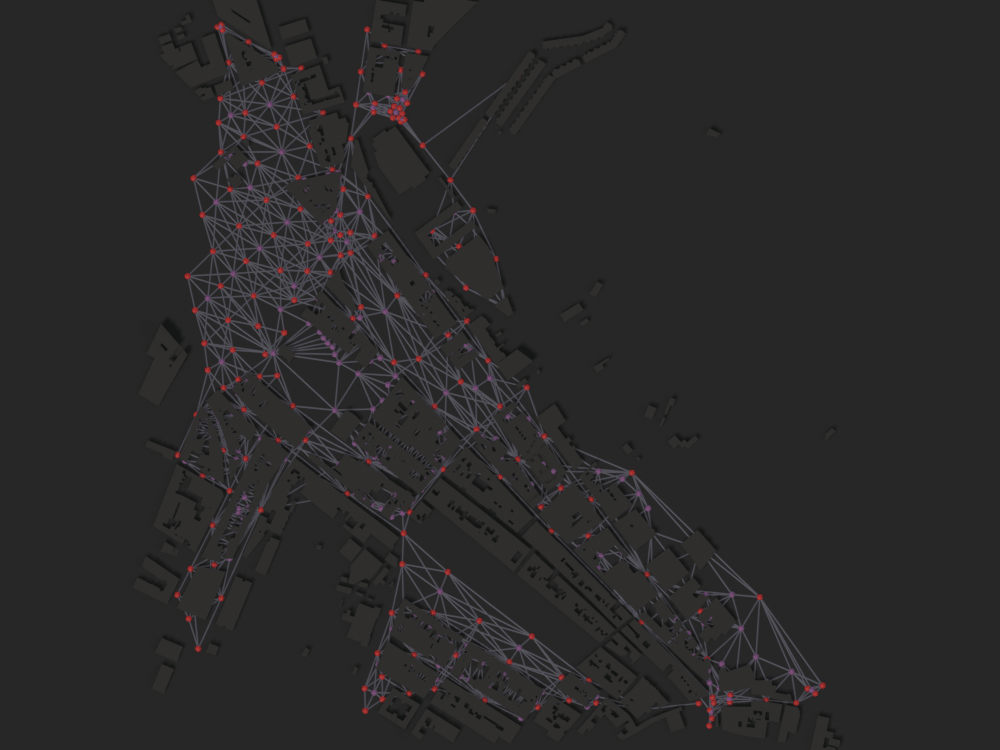

[PASS] 4_morphological_context.png legible — 10.6% ink (healthy range 0.5–100%)


In [17]:
# The 0.35 default is calibrated from the graph's median nearest-neighbor
# distance, and this graph interleaves cell and segment layers, so 0.35 draws
# spheres the size of a city block. Turbo's dark endpoints mean area is the
# only term left: 0.14 gave the colored part 1038 pixels, 0.30 gives 7300.
#
# The primal graph from section 2 hides because `isolate=False` would render it
# too, at its own larger `node_fraction`, over the same intersections.
if obj_primal is not None:
    obj_primal.hide_render = True

path = nb.render(obj_morpho,
                 "renders/09_morphology/4_morphological_context",
                 isolate=False, look='ink',
                 color_attribute="layer_id",
                 edge_color=LAYER_EDGE_COLOR,
                 node_fraction=0.30, verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

if obj_primal is not None:
    obj_primal.hide_render = False

## 5 · Visualize

Without the Geometry Nodes tree that `setup_visualization()` builds, the graph
is a wireframe: correct, but nearly invisible.

In [18]:
sg.graphs.visualize(obj_morpho, node_size=0.02, edge_thickness=0.004)
sg.graphs.color_by(obj_morpho, "layer_id", colormap="viridis")
sg.graphs.frame(obj_morpho)

print("Look at the Blender window: blue = plots (private), "
      "yellow = street segments (public).")

  Promoted 3 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> layer_id  ·  layer_id -> viridis [log]  [0 … 1] on Point
Look at the Blender window: blue = plots (private), yellow = street segments (public).


## 6 · What can be measured on this

The SciGraphs analysis operators act on this graph as on any other. On the
city2graph side, the heterograph converts to NetworkX losslessly, both ways.

In [19]:
G_hetero = c2g.gdf_to_nx(nodes=nodes_dict, edges=edges_dict)
print(f"NetworkX: {G_hetero.number_of_nodes()} nodes, "
      f"{G_hetero.number_of_edges()} edges")

nodes_back, edges_back = c2g.nx_to_gdf(G_hetero, nodes=True, edges=True)
total_out = sum(len(v) for v in nodes_dict.values())
total_back = sum(len(v) for v in nodes_back.values()) if isinstance(nodes_back, dict) else len(nodes_back)
check("gdf -> nx -> gdf preserves the node count",
      total_out == total_back, f"{total_out} vs {total_back}")

NetworkX: 1795 nodes, 2219 edges
[PASS] gdf -> nx -> gdf preserves the node count — 1795 vs 1795


True

## 7 · Save

In [20]:
out_dir = nb.out("13_morphology")
out_dir.mkdir(parents=True, exist_ok=True)

sg.graphs.save_gdf(nodes_dict["private"], out_dir / "private.gpkg")
sg.graphs.save_gdf(nodes_dict["public"], out_dir / "public.gpkg")
sg.graphs.save_gdf(cells, out_dir / "tessellation.gpkg")

print("written to", nb.rel(out_dir))
for f in sorted(out_dir.iterdir()):
    print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/13_morphology
   private.gpkg 2175 kB
   public.gpkg 139 kB
   tessellation.gpkg 356 kB


## 8 · Optional: the same morphology from Overture Maps

`load_overture_data()` reads remote GeoParquet: **several minutes** for a
neighborhood, tens of them for a city. Set `RUN_OVERTURE = True` when you
have the time.

Do not skip `process_overture_segments()`. It splits the segments at the
connectors, groups endpoints with slightly different coordinates and reads the
metadata to flag impassable segments. It also creates the `barrier_geometry`
column that `morphological_graph()` looks for in `primary_barrier_col`.

In [21]:
RUN_OVERTURE = False

if RUN_OVERTURE:
    import math

    lat, lon = CENTER
    degrees = RADIUS_M / 111_000.0
    bbox = [lon - degrees / math.cos(math.radians(lat)), lat - degrees,
            lon + degrees / math.cos(math.radians(lat)), lat + degrees]

    data = c2g.load_overture_data(
        bbox, types=["building", "segment", "connector"],
        save_to_file=False, return_data=True)
    print({k: len(v) for k, v in data.items()})

    seg_ov = c2g.process_overture_segments(
        data["segment"].to_crs(METRIC_CRS),
        connectors_gdf=data["connector"].to_crs(METRIC_CRS),
        get_barriers=True)

    nodes_ov, edges_ov = c2g.morphological_graph(
        buildings_gdf=data["building"].to_crs(METRIC_CRS),
        segments_gdf=seg_ov,
        center_point=center_m, distance=RADIUS_M, clipping_buffer=100.0)

    nb.describe_hetero(nodes_ov, edges_ov)
    sg.graphs.from_hetero(nodes_ov, edges_ov, name="Morphological_Graph_Overture",
                          ref=anchor, coll="C2G_Morphology_Overture")
else:
    print("Overture disabled. Set RUN_OVERTURE to True to try it.")

Overture disabled. Set RUN_OVERTURE to True to try it.


## Rendering, in more detail

`nb.render()` does four things before firing.

It sizes the Geometry Nodes glyphs. The tree bakes node radius and edge
thickness into its primitive nodes at build time and exposes no socket for
them, so the sizes are written on the object and the tree rebuilt. The radius
comes from the median nearest-neighbor distance. The default 0.02 Blender
units suits an abstract graph about ten units across; a neighborhood at
`scale=0.001` measures about one.

It frames the camera with `camera_fit_coords` against the render aspect, so
the resolution is set first. Straight down and orthographic, both by default:
a vertical edge at the corner of the frame splays 14.4 px under perspective
and 39.0 px from an oblique angle, against 0.0 px here, and on a map that lean
is read as geometry. `view='OBLIQUE'` is for figures about relief or height.

It lights the scene with three suns. A sun's strength is an irradiance and
does not fall off with distance, so one rig is correctly exposed at
`scale=0.001` and at 1:1. A `Light Path` node shows the world one color to
the camera and a brighter one to the surfaces, so the backdrop stays
near-black without the unlit side of every node sphere going with it.

And it checks legibility from the fraction of pixels carrying ink: above 60 %
the nodes have merged into a blob, below 0.5 % there is nothing to see. That
ceiling assumes an empty field, so the overhead context views raise it.

`color_attribute=` colors on the freshly rebuilt tree, so the mapping
survives the rebuild. `look=` picks one of five backdrop/palette pairs, each
naming a colormap measured to stay clear of its own backdrop at both ends;
notebooks 00 to 07 all pass `'ink'`. The view transform is `Standard`, not
`AgX`, which rolls off highlights and desaturates. The PNGs land in
`notebooks/out/renders/`.

> Applies to the SciGraphs engine, not to EEVEE: on Blender's **Vulkan**
> backend, the default on Linux, `gpu.state.point_size_set` does nothing for
> the add-on's shaders, so `POINT` and `DISK` nodes come out **1 pixel** wide.
> Start Blender with `--gpu-backend opengl` for any render you intend to look
> at.

## Summary

| Step | city2graph function | Result in Blender |
|---|---|---|
| Primal graph | `segments_to_graph()` | `Primal_Streets` |
| Plots | `create_tessellation(primary_barriers=…)` | `Tessellation` |
| Heterogeneous graph | `morphological_graph()` | `Morphological_Graph` |

Next: **02 · Transport (GTFS)**.

In [22]:
print("Objects in the scene:")
for obj in bpy.data.objects:
    print(f"  {obj.name:<32} {obj.type}")

Objects in the scene:
  Anchor_Morphology                EMPTY
  Buildings                        MESH
  Context_Buildings                MESH
  Context_Ground                   MESH
  Morphological_Graph              MESH
  Primal_Streets                   MESH
  SciGraphs_Camera                 CAMERA
  SciGraphs_Fill                   LIGHT
  SciGraphs_Key                    LIGHT
  SciGraphs_Rim                    LIGHT
  Tessellation                     MESH
